In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.gridspec import GridSpec


In [2]:
df1 = pd.read_csv('../Data/Figures_2-3-4/cells_concat_raw_1.csv', index_col=0)
df2 = pd.read_csv('../Data/Figures_2-3-4/cells_concat_raw_2.csv', index_col=0)
df = pd.concat([df1, df2], ignore_index=True)

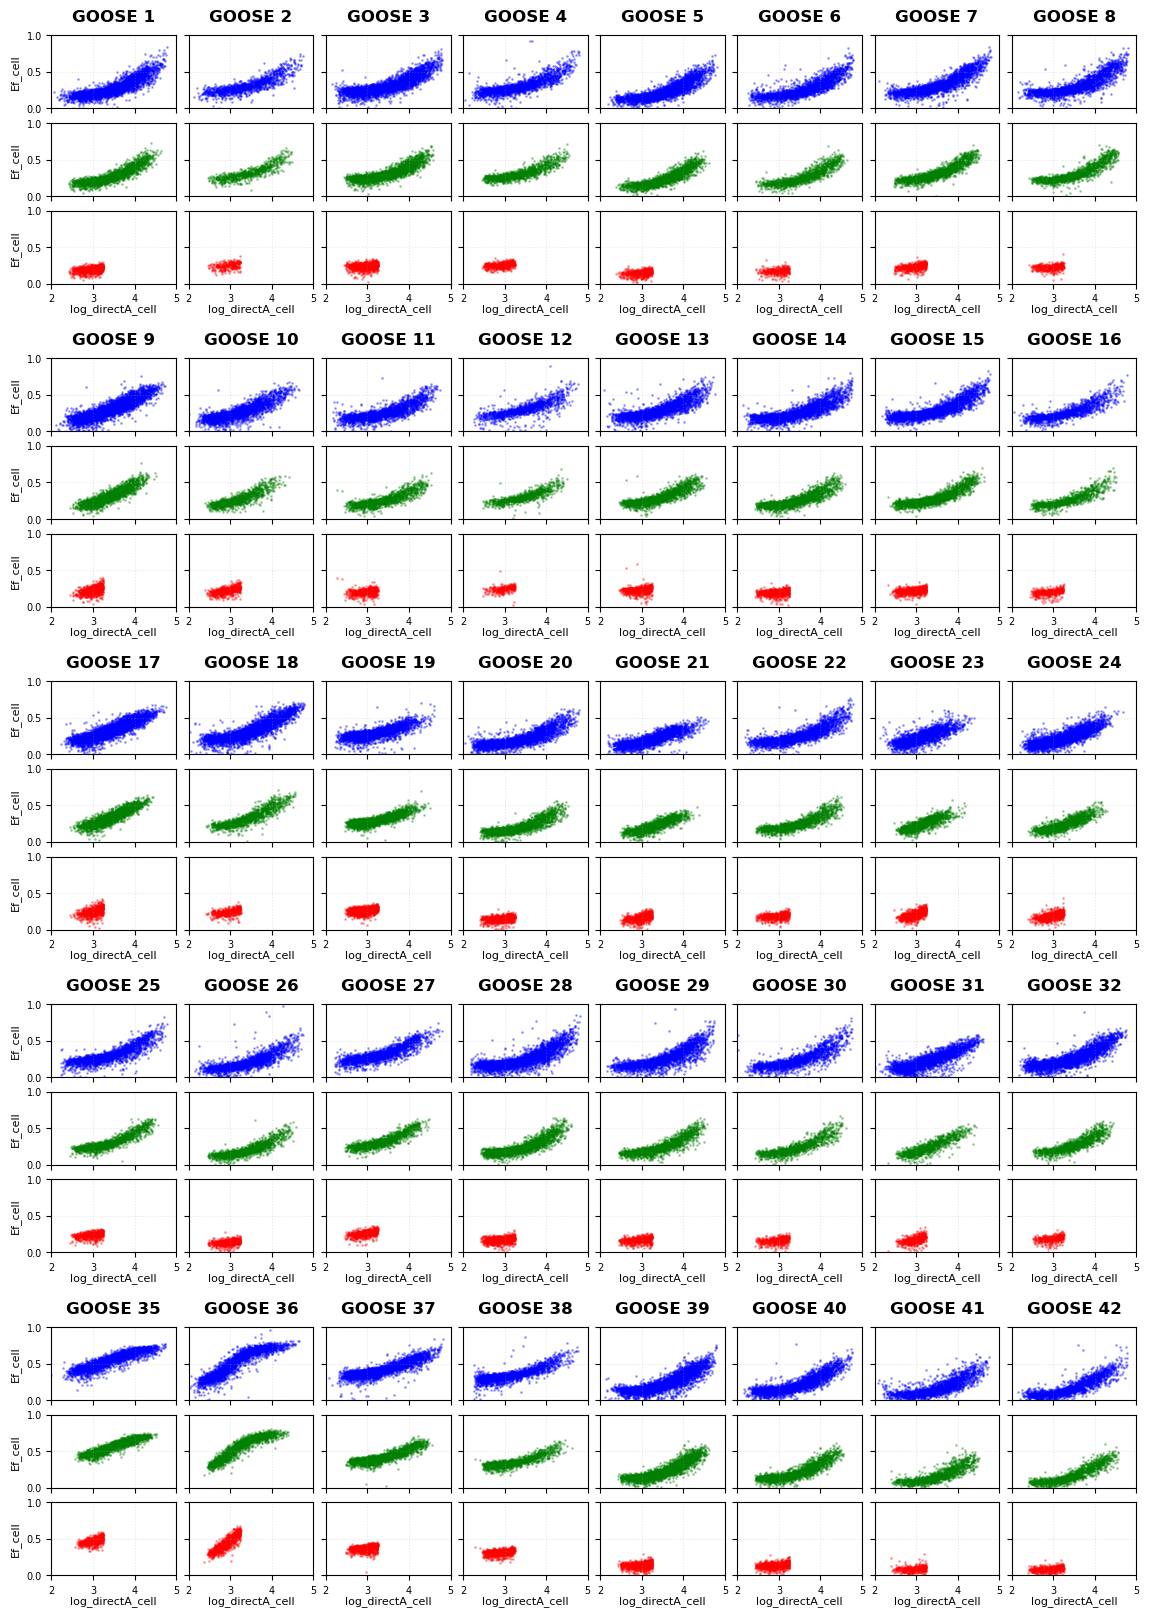

In [3]:
# Create a large figure with all constructs showing filtering progression
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid dimensions for construct layout
constructs_per_row = 8
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 3 rows for the 3 filtering stages
rows_per_construct = 3

# Create figure
fig = plt.figure(figsize=(14, 4 * n_row_blocks))

# Create outer GridSpec for construct groups (with large spacing between constructs)
outer_gs = GridSpec(n_row_blocks, constructs_per_row, figure=fig, 
                    hspace=0.3, wspace=0.1)  # Spacing BETWEEN constructs

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate position in overall grid
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct].copy()
    
    # Create inner GridSpec for this construct's 3 subplots (with minimal spacing)
    inner_gs = outer_gs[row_block, col_in_block].subgridspec(3, 1, 
                                                              hspace=0.2)  # Minimal spacing WITHIN construct
    
    # --- SUBPLOT 1: Unfiltered data ---
    ax1 = fig.add_subplot(inner_gs[0])
    
    if len(construct_data) > 0:
        ax1.scatter(construct_data['log_directA_cell'], construct_data['Ef_cell'], 
                   s=1, alpha=0.3, c='blue')
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=10)
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    
    # Add construct title only on first subplot
    ax1.set_title(f'GOOSE {int(construct)}', 
                 fontsize=12, fontweight='bold', pad=10)
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax1.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax1.set_yticklabels([])
    ax1.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax1.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 1 ---
    filtered_data = construct_data[
        (construct_data['directA_cell_max'] >= 400) &
        (construct_data['directA_cell_max'] <= 65000) &
        (construct_data['directA_cell_delta_ratio'] > 0.8) &
        (construct_data['directA_cell_delta_ratio'] < 1.1) &
        (construct_data['circ_cell_original'] < 0.8) &
        (construct_data['circ_cell_original'] > 0.3) &
        (construct_data['nuc_area_ratio'] < 0.75) &
        (construct_data['nuc_area_ratio'] > 0.05) &
        (construct_data['A_cell_corr'] > 0) &
        (construct_data['area_cell'] > 2000) &
        (construct_data['area_cell'] < 25000) &
        (construct_data['area_nuc'] < 5000) &
        (construct_data['area_nuc'] > 600)
    ].copy()
    
    # --- SUBPLOT 2: Filter 1 applied ---
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    if len(filtered_data) > 0:
        ax2.scatter(filtered_data['log_directA_cell'], filtered_data['Ef_cell'], 
                   s=1, alpha=0.3, c='green')
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=10)
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax2.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax2.set_yticklabels([])
    ax2.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax2.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 2 ---
    filtered_data2 = filtered_data[
        (filtered_data['log_directA_cell'] < 3.25) &
        (filtered_data['log_directA_cell'] > 2)
    ].copy()
    
    # --- SUBPLOT 3: Filter 2 applied ---
    ax3 = fig.add_subplot(inner_gs[2], sharex=ax1)
    
    if len(filtered_data2) > 0:
        ax3.scatter(filtered_data2['log_directA_cell'], filtered_data2['Ef_cell'], 
                   s=1, alpha=0.3, c='red')
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=10)
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    
    ax3.set_xlabel('log_directA_cell', fontsize=8, labelpad=0)
    # Only show y-axis label for first column
    if col_in_block == 0:
        ax3.set_ylabel('Ef_cell', fontsize=8)
    if col_in_block != 0:
        ax3.set_yticklabels([])
    ax3.tick_params(labelsize=7)  # Keep x-axis labels for bottom plot
    ax3.grid(True, linestyle=':', alpha=0.3)

#plt.savefig('ConcentrationFilters.svg', bbox_inches='tight')
plt.show()